Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['d2c-churn-part1-eda', 'd2c-churn-part2-rfm', 'd2c-churn-part3-model']
['data', 'output']
['d2c churn data package-20260524T075155Z-3-001.zip', 'd2c churn data package']
ZIP Extracted Successfully
['d2c churn data package-20260524T075155Z-3-001.zip', 'd2c churn data package']
['churn_labels.csv', 'web_events_snapshot.csv', 'customers.csv', 'intervention_history.csv', 'rfm_modeling_snapshot.csv', 'orders.csv', 'STUDENT_FACING_PROBLEM_STATEMENT.md', 'support_tickets.csv', 'DATA_DICTIONARY.md']
All datasets loaded successfully
  customer_id snapshot_date_x city_tier age_group acquisition_channel  \
0   CUST00001      2025-09-30    Tier 1     18-24           Instagram   
1   CUST00002      2025-09-30    Tier 2     25-34         Marketplace   
2   CUST00003      2025-09-30    Tier 1     25-34          Influencer   
3   CUST00004      2025-09-30    Tier 3     25-3

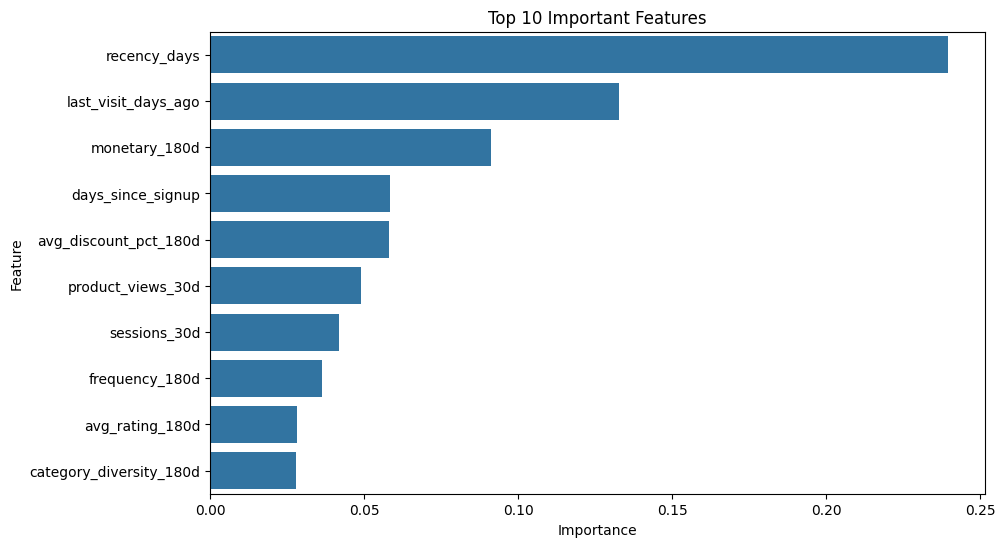

Model Saved
Metrics Saved
False Positives
      city_tier  age_group  acquisition_channel  loyalty_tier  \
436           1          2                    3             2   
1203          0          1                    4             0   
1016          0          0                    1             3   
1839          1          1                    1             1   
1404          1          1                    5             0   

      preferred_category  marketing_consent  recency_days  frequency_180d  \
436                    0                  1           151               1   
1203                   4                  1            81               1   
1016                   4                  1           133               2   
1839                   4                  1           101               1   
1404                   4                  0           140               1   

      monetary_180d  return_rate_180d  ...  product_views_30d  cart_adds_30d  \
436          729.22     

In [13]:
# ============================================
# PART 3 — CHURN PREDICTION MODEL
# ============================================

# INSTALL / IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pickle
import json
import warnings

warnings.filterwarnings('ignore')

# ============================================
# MOUNT GOOGLE DRIVE
# ============================================

drive.mount('/content/drive')

# ============================================
# CHECK FOLDER
# ============================================

import os

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/'))

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/'))

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/'))

# ============================================
# EXTRACT ZIP FILE
# ============================================

from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/d2c churn data package-20260524T075155Z-3-001.zip"

extract_path = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")

# ============================================
# CHECK EXTRACTED FILES
# ============================================

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/'))

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/d2c churn data package'))

# ============================================
# LOAD DATASETS
# ============================================

BASE_PATH = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/data/d2c churn data package/"

customers = pd.read_csv(BASE_PATH + "customers.csv")

orders = pd.read_csv(BASE_PATH + "orders.csv")

tickets = pd.read_csv(BASE_PATH + "support_tickets.csv")

campaigns = pd.read_csv(BASE_PATH + "intervention_history.csv")

labels = pd.read_csv(BASE_PATH + "churn_labels.csv")

rfm_snapshot = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")

print("All datasets loaded successfully")

# ============================================
# MERGE DATA
# ============================================

df = rfm_snapshot.merge(
    labels,
    on='customer_id',
    how='left'
)

print(df.head())

print(df.columns)

# ============================================
# HANDLE CATEGORICAL COLUMNS
# ============================================

categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:

    df[col] = df[col].astype(str)

    df[col] = le.fit_transform(df[col])

# ============================================
# TARGET VARIABLE
# ============================================

target = 'churn_next_60d_x'

# ============================================
# FEATURE / TARGET SPLIT
# ============================================

X = df.drop(columns=[
    'customer_id',
    'churn_next_60d_x',
    'churn_next_60d_y',
    'split_x',
    'split_y',
    'snapshot_date_x',
    'snapshot_date_y'
])

y = df[target]

print(X.shape)

print(y.shape)

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

# ============================================
# BASELINE MODEL
# ============================================

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:,1]

# ============================================
# RANDOM FOREST MODEL
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

# ============================================
# EVALUATION
# ============================================

accuracy = accuracy_score(y_test, rf_pred)

precision = precision_score(y_test, rf_pred)

recall = recall_score(y_test, rf_pred)

f1 = f1_score(y_test, rf_pred)

roc_auc = roc_auc_score(y_test, rf_prob)

cm = confusion_matrix(y_test, rf_pred)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("ROC AUC:", roc_auc)

print(cm)

print(classification_report(y_test, rf_pred))

# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

# ============================================
# FEATURE IMPORTANCE CHART
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# ============================================
# SAVE MODEL
# ============================================

model_path = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/output/model.pkl"

pickle.dump(rf_model, open(model_path, 'wb'))

print("Model Saved")

# ============================================
# SAVE METRICS
# ============================================

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "threshold": 0.5,
    "confusion_matrix": cm.tolist()
}

metrics_path = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/output/metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f)

print("Metrics Saved")

# ============================================
# FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# ============================================

results = X_test.copy()

results['actual'] = y_test.values

results['predicted'] = rf_pred

results['probability'] = rf_prob

false_positive = results[
    (results['actual'] == 0) &
    (results['predicted'] == 1)
]

false_negative = results[
    (results['actual'] == 1) &
    (results['predicted'] == 0)
]

print("False Positives")

print(false_positive.head())

print("False Negatives")

print(false_negative.head())

# ============================================
# SAVE SAMPLE ERROR FILES
# ============================================

false_positive.head(10).to_csv(
    "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/output/false_positive.csv",
    index=False
)

false_negative.head(10).to_csv(
    "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part3-model/output/false_negative.csv",
    index=False
)

print("Error Analysis Files Saved")